# US TAXING

In [36]:
import numpy as np 
import matplotlib.pyplot as plt

In [50]:
def after_tax_income_single(gross_income):

    # 2025 standard deduction (single filer)
    standard_deduction = 15_750
    taxable_income = max(0, gross_income - standard_deduction)

    # Federal income tax brackets (single filer, 2025)
    brackets = [
        (11925, 0.10),
        (48475, 0.12),
        (103350, 0.22),
        (197300, 0.24), 
        (250525, 0.32), 
(626350, 0.35)  
    ]

    federal_tax = 0
    prev_limit = 0

    for limit, rate in brackets:
        if taxable_income > limit:
            federal_tax += (limit - prev_limit) * rate
            prev_limit = limit
        else:
            federal_tax += (taxable_income - prev_limit) * rate
            break

    # Payroll taxes (no Social Security for retirement-age brackets: 75460, 56028)
    social_security = 0 if gross_income in (75460, 56028) else min(0.062 * gross_income, 184500)
    medicare = 0.0145 * gross_income

    total_tax = federal_tax + social_security + medicare
    net_income = gross_income - total_tax

    return round(net_income, 2)


def after_tax_income_married(gross_income):

    # 2025 standard deduction (single filer)
    standard_deduction = 31_500
    taxable_income = max(0, gross_income - standard_deduction)

    # Federal income tax brackets (single filer, 2025)
    brackets = [
        (23850, 0.10),
        (96950 , 0.12),
        (206700, 0.22),
        (394600 , 0.24), 
        (501050 , 0.32), 
(751600 , 0.35)  
    ]

    federal_tax = 0
    prev_limit = 0

    for limit, rate in brackets:
        if taxable_income > limit:
            federal_tax += (limit - prev_limit) * rate
            prev_limit = limit
        else:
            federal_tax += (taxable_income - prev_limit) * rate
            break

    # Payroll taxes (no Social Security for retirement-age brackets: 75460, 56028)
    social_security = 0 if gross_income in (75460, 56028) else min(0.062 * gross_income, 184500)
    medicare = 0.0145 * gross_income

    total_tax = federal_tax + social_security + medicare
    net_income = gross_income - total_tax

    return round(net_income, 2)




In [53]:
## single calculations

gross_values_ages = [48514, 102494, 128285, 141121, 121571, 75460, 56028]
gross_values_states = [115770, 97104, 93814, 120365]

# Compute after-tax income for each gross value (used as after_tax_single below)
after_tax_age_single = np.array([after_tax_income_single(g) for g in gross_values_ages])
after_tax_age_married = np.array([after_tax_income_married(g) for g in gross_values_ages])

after_tax_state_single = np.array([after_tax_income_single(g) for g in gross_values_states])
after_tax_state_married = np.array([after_tax_income_married(g) for g in gross_values_states])

print("single jits")
print(f"{'Gross':>12} {'Tax':>12} {'Net':>12}")
print("-" * 38)
for i, g in enumerate(gross_values_ages):
    net = after_tax_age_single[i]
    tax = g - net
    print(f"${g:>10,} ${tax:>10,.2f} ${net:>10,.2f}")

print("married jits")
print(f"{'Gross':>12} {'Tax':>12} {'Net':>12}")
print("-" * 38)
for i, g in enumerate(gross_values_ages):
    net = after_tax_age_married[i]
    tax = g - net
    print(f"${g:>10,} ${tax:>10,.2f} ${net:>10,.2f}")



single jits
       Gross          Tax          Net
--------------------------------------
$    48,514 $  7,404.50 $ 41,109.50
$   102,494 $ 21,838.47 $ 80,655.53
$   128,285 $ 29,669.20 $ 98,615.80
$   141,121 $ 33,731.80 $107,389.20
$   121,571 $ 27,544.22 $ 94,026.78
$    75,460 $  9,144.37 $ 66,315.63
$    56,028 $  5,407.27 $ 50,620.73
married jits
       Gross          Tax          Net
--------------------------------------
$    48,514 $  5,412.72 $ 43,101.28
$   102,494 $ 15,883.07 $ 86,610.93
$   128,285 $ 20,951.00 $107,334.00
$   141,121 $ 24,740.38 $116,380.62
$   121,571 $ 19,631.70 $101,939.30
$    75,460 $  5,892.37 $ 69,567.63
$    56,028 $  3,278.77 $ 52,749.23


[ 97278.2   82280.06  79636.55 100970.28]
[-3802.84  9535.94 10525.39 14638.98 14152.43 -2561.94 -8561.69]


In [39]:
## married calculations

for g in gross_values:
    net = after_tax_income_married(g)
    tax = g - net
    print(f"${g:>10,} ${tax:>10,.2f} ${net:>10,.2f}")

$    48,514 $  5,412.72 $ 43,101.28
$   102,494 $ 15,883.07 $ 86,610.93
$   128,285 $ 20,951.00 $107,334.00
$   141,121 $ 24,740.38 $116,380.62
$   121,571 $ 19,631.70 $101,939.30
$    75,460 $ 10,570.89 $ 64,889.11
$    56,028 $  6,752.50 $ 49,275.50
$   115,770 $ 18,491.80 $ 97,278.20
$    97,104 $ 14,823.94 $ 82,280.06
$    93,814 $ 14,177.45 $ 79,636.55
$   120,365 $ 19,394.72 $100,970.28


In [40]:
after_tax_single = np.array([39089.66,	76376.54,	93247.69,	101475.56,	88944.01,	58507.06, 	44807.81])
age = np.array([(25+18)/2, (34+25)/2, (44+35)/2, (54+45)/2, (64+55)/2, (74+65)/2, (78+75)/2]) #av

after_tax_married = np.array([39328.16,	80406.94,	98510.39,	106994.98,	94072.43,	59834.06, 	45046.31])
age = np.array([(25+18)/2, (34+25)/2, (44+35)/2, (54+45)/2, (64+55)/2, (74+65)/2, (78+75)/2]) #averaging age brackets, maybe make better lattr

necessary_expenses_age = np.array([43_131, 70_871, 87_985, 92_356, 79_920, 62_396, 53_608])
necessary_expenses_states = np.array([79_267, 69_498, 67_463, 86_936])

disposable_income_single = after_tax_single - necessary_expenses_age
disposable_income_married = after_tax_married - necessary_expenses_age

# plt.title("Age vs disposable income")
# plt.scatter(age, disposable_income)
# plt.show()

proportion_single = disposable_income_single/after_tax_single
proportion_married = disposable_income_married/after_tax_married


In [48]:



print(after_tax_age_married)
print(disposable_income_married)

[ 43101.28  86610.93 107334.   116380.62 101939.3   64889.11  49275.5 ]
[-3802.84  9535.94 10525.39 14638.98 14152.43 -2561.94 -8561.69]


In [43]:
print(disposable_income_single)
print(disposable_income_married)

[-4041.34  5505.54  5262.69  9119.56  9024.01 -3888.94 -8800.19]
[-3802.84  9535.94 10525.39 14638.98 14152.43 -2561.94 -8561.69]


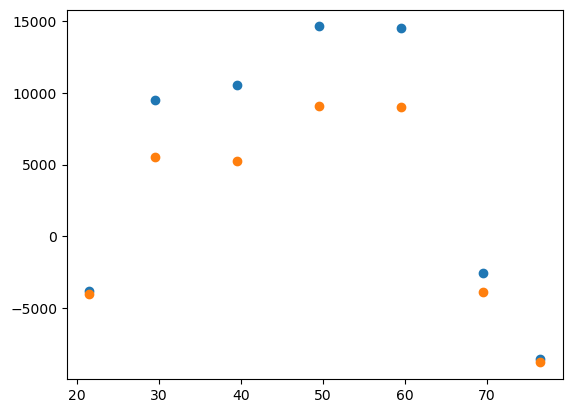

In [ ]:
plt.scatter(age, disposable_income_married) 
plt.scatter(age, disposable_income_single)

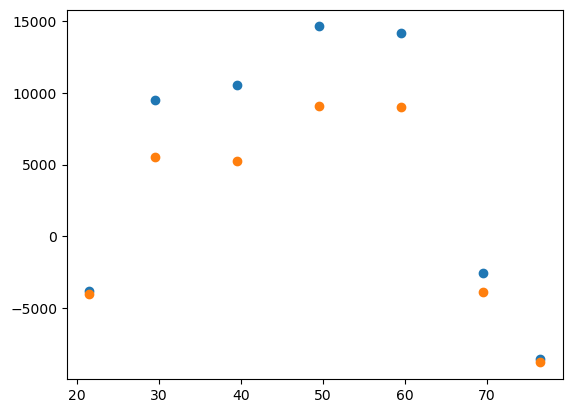

In [41]:
plt.scatter(age, disposable_income_married) 
plt.scatter(age, disposable_income_single)

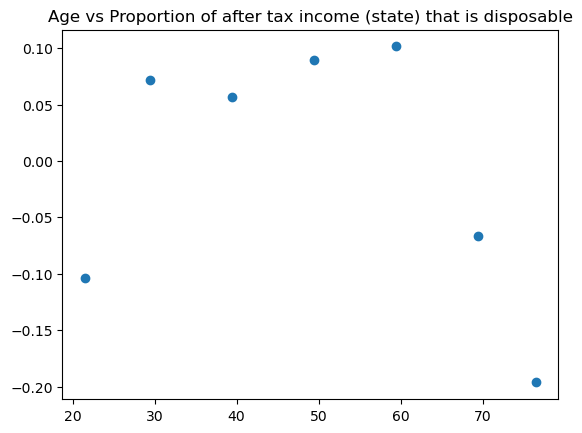

In [10]:
plt.title("Age vs Proportion of after tax income (state) that is disposable")
plt.scatter(age, disposable_income_single/after_tax_single)
#plt.show()

# UK TAXING

In [ ]:
def after_tax_income_single_uk(gross_income):

    # 2025 standard deduction (single filer)
    standard_deduction = 15_750
    taxable_income = max(0, gross_income - standard_deduction)

    # Federal income tax brackets (single filer, 2025)
    brackets = [
        (11925, 0.10),
        (48475, 0.12),
        (103350, 0.22),
        (197300, 0.24), 
        (250525, 0.32), 
(626350, 0.35)  
    ]

    federal_tax = 0
    prev_limit = 0

    for limit, rate in brackets:
        if taxable_income > limit:
            federal_tax += (limit - prev_limit) * rate
            prev_limit = limit
        else:
            federal_tax += (taxable_income - prev_limit) * rate
            break

    # Payroll taxes
    social_security = min(0.062 * gross_income, 184500)
    medicare = 0.0145 * gross_income

    total_tax = federal_tax + social_security + medicare
    net_income = gross_income - total_tax

    return round(net_income, 2)

# CHOPPED IPYNB

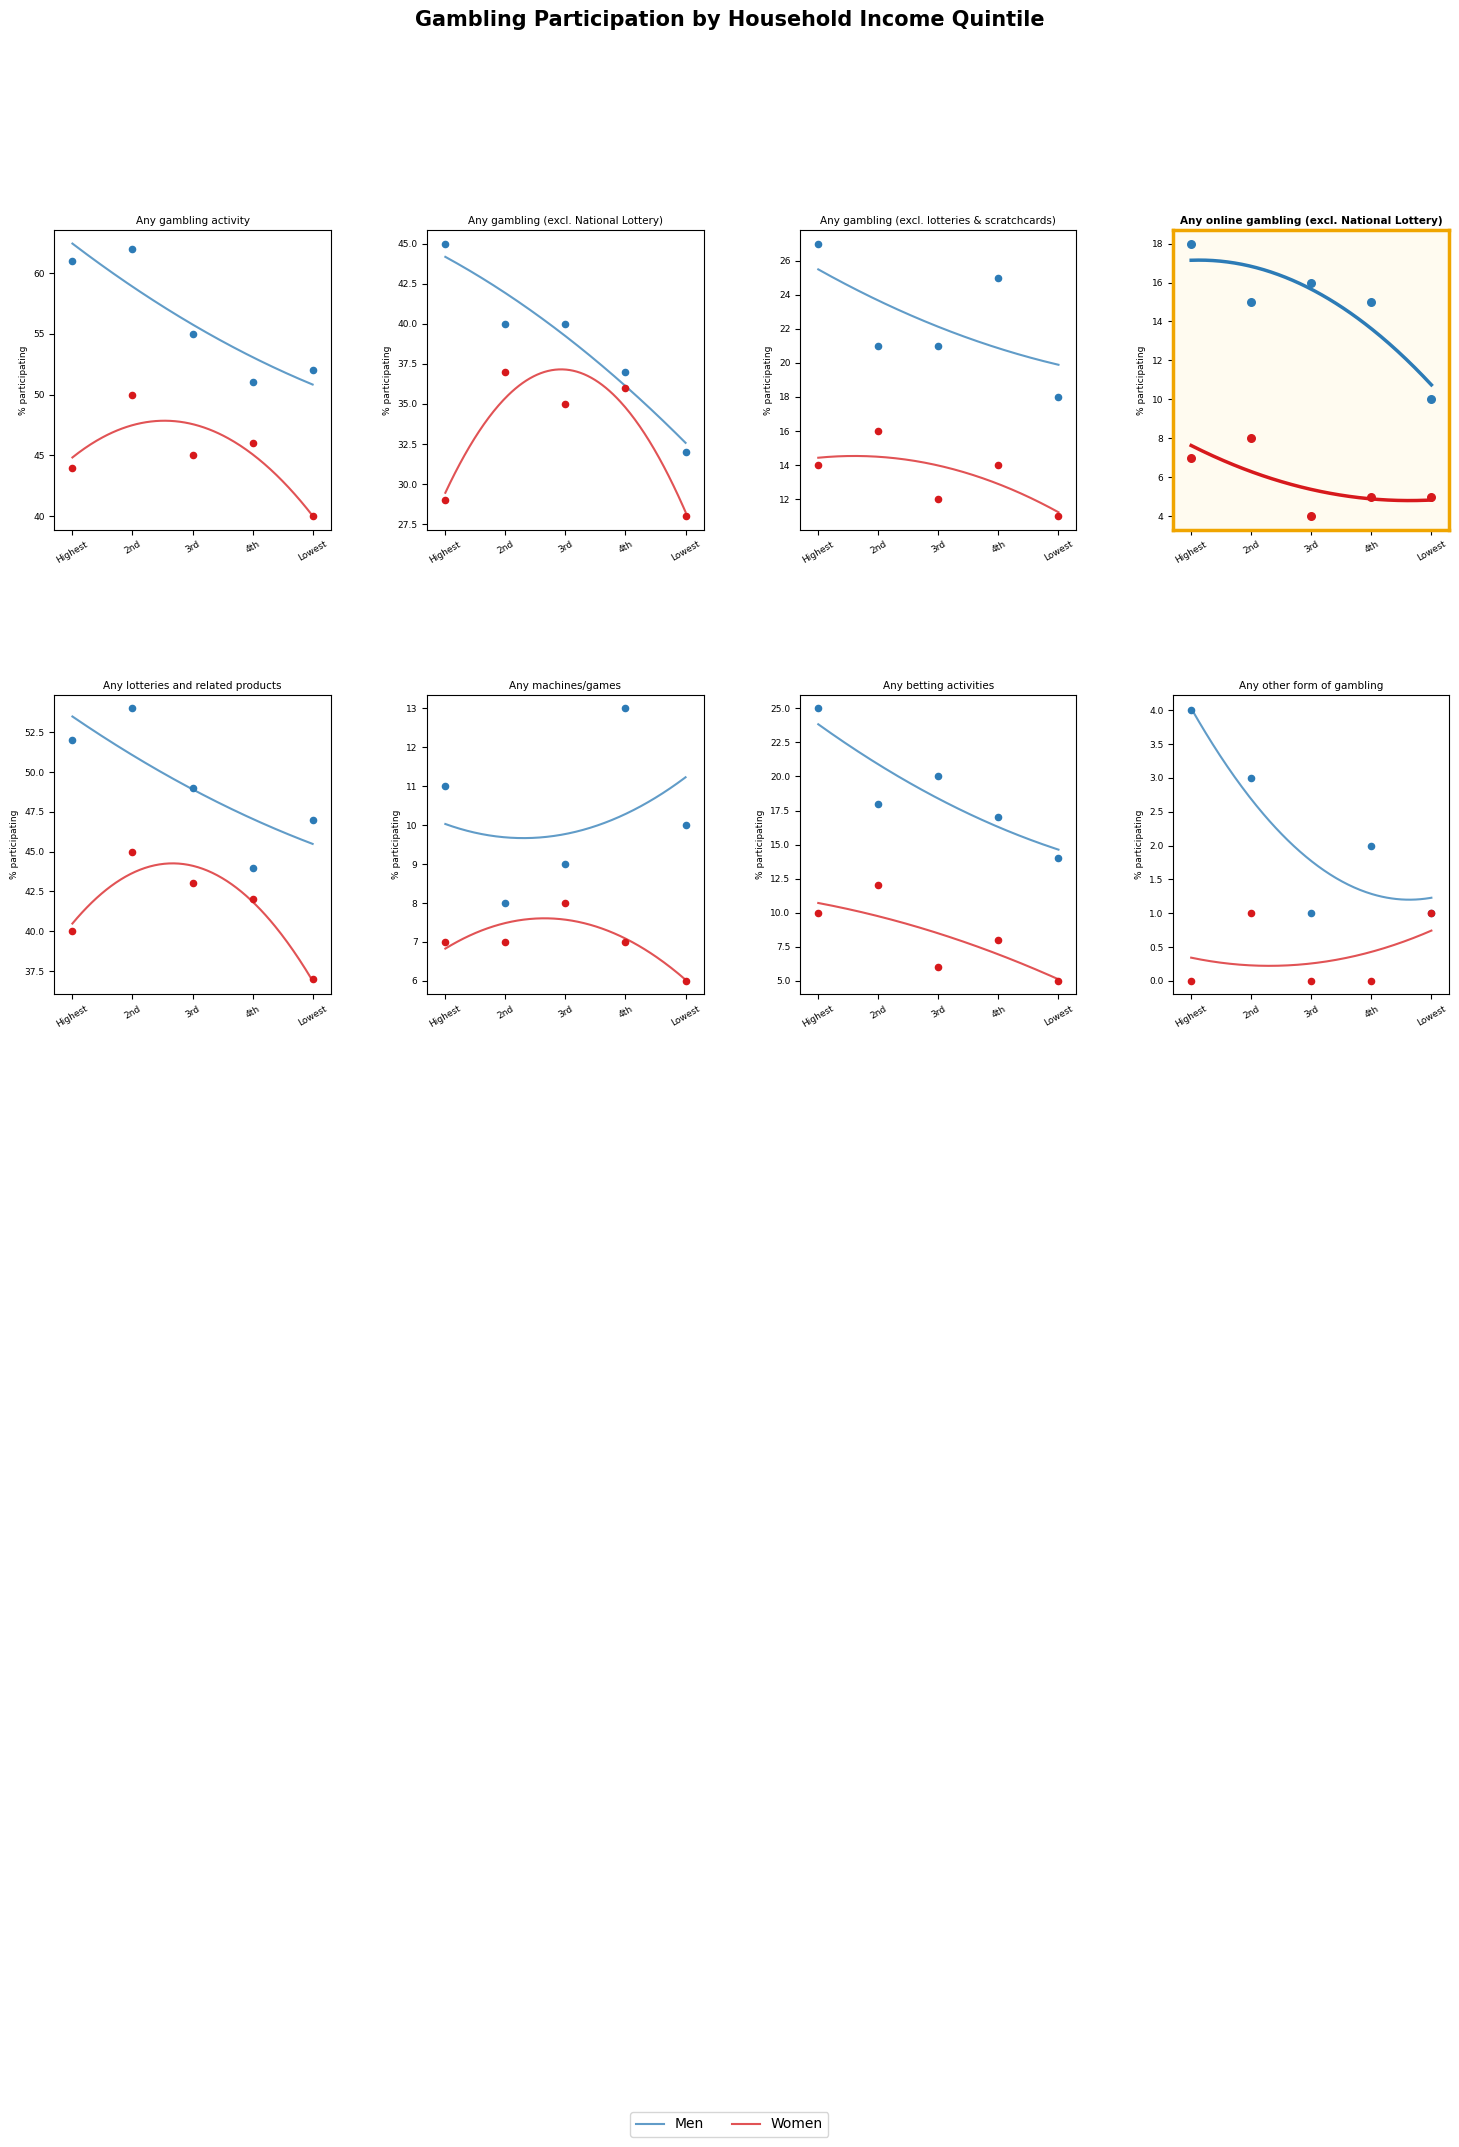

Saved to gambling_by_income_quintile.png


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

quintiles = np.array([1, 2, 3, 4, 5])
quintile_labels = ['Highest', '2nd', '3rd', '4th', 'Lowest']

data = {
    "Men": {
        "Any gambling activity":                          [61, 62, 55, 51, 52],
        "Any gambling (excl. National Lottery)":          [45, 40, 40, 37, 32],
        "Any gambling (excl. lotteries & scratchcards)":  [27, 21, 21, 25, 18],
        "Any online gambling (excl. National Lottery)":   [18, 15, 16, 15, 10],
        "Any lotteries and related products":             [52, 54, 49, 44, 47],
        "Any machines/games":                             [11,  8,  9, 13, 10],
        "Any betting activities":                         [25, 18, 20, 17, 14],
        "Any other form of gambling":                     [ 4,  3,  1,  2,  1],
    },
    "Women": {
        "Any gambling activity":                          [44, 50, 45, 46, 40],
        "Any gambling (excl. National Lottery)":          [29, 37, 35, 36, 28],
        "Any gambling (excl. lotteries & scratchcards)":  [14, 16, 12, 14, 11],
        "Any online gambling (excl. National Lottery)":   [ 7,  8,  4,  5,  5],
        "Any lotteries and related products":             [40, 45, 43, 42, 37],
        "Any machines/games":                             [ 7,  7,  8,  7,  6],
        "Any betting activities":                         [10, 12,  6,  8,  5],
        "Any other form of gambling":                     [ 0,  1,  0,  0,  1],
    }
}

TARGET = "Any online gambling (excl. National Lottery)"

fig = plt.figure(figsize=(18, 22))
fig.suptitle("Gambling Participation by Household Income Quintile", fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.35)

x_smooth = np.linspace(1, 5, 200)
colors = {'Men': '#2c7bb6', 'Women': '#d7191c'}

axes = []
categories = list(data["Men"].keys())

for i, category in enumerate(categories):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    axes.append(ax)
    is_target = (category == TARGET)

    for gender in ["Men", "Women"]:
        y = np.array(data[gender][category])
        color = colors[gender]
        lw = 2.5 if is_target else 1.5
        alpha = 1.0 if is_target else 0.75

        ax.scatter(quintiles, y, color=color, zorder=5, s=30 if is_target else 20)

        coeffs = np.polyfit(quintiles, y, deg=2)
        p = np.poly1d(coeffs)
        ax.plot(x_smooth, p(x_smooth), color=color, lw=lw, alpha=alpha, label=gender)

    if is_target:
        for spine in ax.spines.values():
            spine.set_edgecolor('#f0a500')
            spine.set_linewidth(2.5)
        ax.set_facecolor('#fffbf0')

    ax.set_title(category, fontsize=7.5, fontweight='bold' if is_target else 'normal', pad=4)
    ax.set_xticks(quintiles)
    ax.set_xticklabels(quintile_labels, fontsize=6.5, rotation=30)
    ax.set_ylabel("% participating", fontsize=6.5)
    ax.tick_params(axis='y', labelsize=6.5)
    ax.set_xlim(0.7, 5.3)
    ax.ymin = 0

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.01))

plt.savefig("gambling_by_income_quintile.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to gambling_by_income_quintile.png")

In [55]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

quintiles = np.array([1, 2, 3, 4, 5], dtype=float)

data = {
    "Men": {
        "Any gambling activity":                          [61, 62, 55, 51, 52],
        "Any gambling (excl. National Lottery)":          [45, 40, 40, 37, 32],
        "Any gambling (excl. lotteries & scratchcards)":  [27, 21, 21, 25, 18],
        "Any online gambling (excl. National Lottery)":   [18, 15, 16, 15, 10],
        "Any lotteries and related products":             [52, 54, 49, 44, 47],
        "Any machines/games":                             [11,  8,  9, 13, 10],
        "Any betting activities":                         [25, 18, 20, 17, 14],
        "Any other form of gambling":                     [ 4,  3,  1,  2,  1],
    },
    "Women": {
        "Any gambling activity":                          [44, 50, 45, 46, 40],
        "Any gambling (excl. National Lottery)":          [29, 37, 35, 36, 28],
        "Any gambling (excl. lotteries & scratchcards)":  [14, 16, 12, 14, 11],
        "Any online gambling (excl. National Lottery)":   [ 7,  8,  4,  5,  5],
        "Any lotteries and related products":             [40, 45, 43, 42, 37],
        "Any machines/games":                             [ 7,  7,  8,  7,  6],
        "Any betting activities":                         [10, 12,  6,  8,  5],
        "Any other form of gambling":                     [ 0,  1,  0,  0,  1],
    }
}

def logistic(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def r_squared(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    if ss_tot == 0:
        return float('nan')
    return 1 - ss_res / ss_tot

print(f"{'Category':<48} {'Gender':<8} {'R² Logistic':>12} {'R² Cubic':>12}")
print("-" * 84)

for gender, categories in data.items():
    for category, values in categories.items():
        y = np.array(values, dtype=float)

        # Cubic fit
        coeffs = np.polyfit(quintiles, y, deg=3)
        y_cubic = np.poly1d(coeffs)(quintiles)
        r2_cubic = r_squared(y, y_cubic)

        # Logistic fit
        try:
            p0 = [max(y), -1, 3]
            popt, _ = curve_fit(logistic, quintiles, y, p0=p0, maxfev=10000)
            y_logistic = logistic(quintiles, *popt)
            r2_logistic = r_squared(y, y_logistic)
        except RuntimeError:
            r2_logistic = float('nan')

        short = category[:47]
        print(f"{short:<48} {gender:<8} {r2_logistic:>12.4f} {r2_cubic:>12.4f}")

Category                                         Gender    R² Logistic     R² Cubic
------------------------------------------------------------------------------------
Any gambling activity                            Men            0.8213       0.9887
Any gambling (excl. National Lottery)            Men            0.9327       0.9873
Any gambling (excl. lotteries & scratchcards)    Men            0.3865       0.9528
Any online gambling (excl. National Lottery)     Men            0.8729       0.9934
Any lotteries and related products               Men            0.6388       0.9998
Any machines/games                               Men            0.0625       0.9218
Any betting activities                           Men            0.8024       0.9228
Any other form of gambling                       Men            0.8013       0.8298
Any gambling activity                            Women          0.6037       0.7527
Any gambling (excl. National Lottery)            Women          0.4464     

--- Running New Exp(Income) / Quad(Age) 3D Regression ---
Exp/Quad 3D Weights (a, b, c, d, f): [-1.21372942e+00 -4.13916033e-05 -1.65247417e-04  1.42036832e-02
  3.18327886e-02]


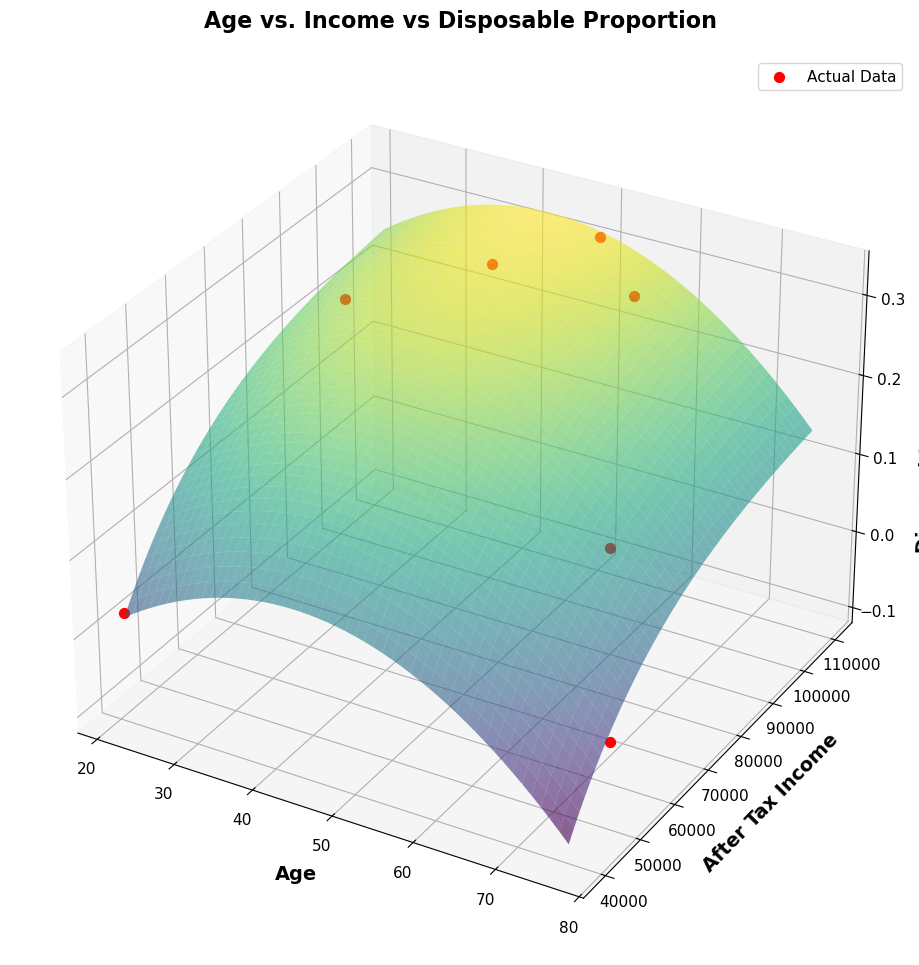

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#ANOTHER POSSIBILITY: graph neccessary income vs age and then subtract that flat amount from inputted after tax income

#change US numbers and do UK

#--legacy info
after_tax_not_including_married = np.array([39089.66,	76376.54,	93247.69,	101475.56,	88944.01,	58507.06, 	44807.81]) 
disposable_income_not_including_married = np.array([-4041.35,	5505.54, 5262.69, 9119.56 ,9024.01,	-3888.94 ,-8800.19])



#assuming everyone above 29.5 is married and everyone below is single 
age = np.array([(25+18)/2, (34+25)/2, (44+35)/2, (54+45)/2, (64+55)/2, (74+65)/2, (78+75)/2]) #averaging age brackets, maybe make better lattr
after_tax = np.array([ 39047.66,	 82254.94,	101881.89,	110383.18,	96772.53,	66360.58,	50368.04 ])
disposable_income = np.array([991.65,	22947.94,	28563.89,	34201.18,	30047.53,	9360.58, -597.96])
# plt.title("Age vs disposable income")
# plt.scatter(age, disposable_income)
# plt.show()


proportion = disposable_income/after_tax

def age_prop_reg():
    plt.title("Age vs Proportion of after tax income (state) that is disposable")
    plt.scatter(age, disposable_income/after_tax)
    #plt.show()

    #interperet age vs proportion disposable income as quartic?? to model mid-life dip due to children entering the house but then leaving house


    X = np.stack([age ** 2, age, np.ones_like(age)]).transpose()
    print(X)

    w = np.linalg.pinv(X) @ proportion
    print(w)

    plt.plot(age, X @ w)
    plt.show()

def show_income_vs_proportion():
    plt.title("Income vs Proportion of after tax income (state) that is disposable")
    X = np.stack([after_tax, np.ones_like(after_tax)]).transpose()
    w = np.linalg.pinv(X) @ proportion
    plt.scatter(after_tax, disposable_income/after_tax)
    print("INCOME VS DISP PROP WEIGHTs", w)
    plt.plot(after_tax, X @ w)
    plt.show()

#CHEF MIKED PLOTRTING FUNC
def plot_3d_regression(age, after_tax, proportion, w):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. Create a grid of values to draw the smooth surface
    age_grid = np.linspace(age.min(), age.max(), 50)
    tax_grid = np.linspace(after_tax.min(), after_tax.max(), 50)
    age_mesh, tax_mesh = np.meshgrid(age_grid, tax_grid)
    
    # 2. Calculate the predicted proportion (Z) for every point on the grid
    # w[0] = age^2, w[1] = age, w[2] = after_tax, w[3] = constant
    Z = w[0] * age_mesh**2 + w[1] * age_mesh + w[2] * tax_mesh + w[3]
    
    # 3. Plot the predicted surface and the actual data points
    ax.plot_surface(age_mesh, tax_mesh, Z, alpha=0.6, cmap='viridis')
    ax.scatter(age, after_tax, proportion, color='red', s=50, label='Actual Data', depthshade=False)
    
    # 4. Labels and display
    ax.set_xlabel('Age')
    ax.set_ylabel('After Tax Income')
    ax.set_zlabel('Disposable Proportion')
    ax.set_title('3D Regression: Age & Income vs Disposable Proportion')
    plt.legend()
    plt.show()


#--- switching over to EXPONENTIAL relationship between income and disp instead of linear

def show_income_vs_proportion_exp():
    plt.title("Income vs Proportion of after tax income (state) that is disposable")
    
    # Define the 1D exponential decay model
    def exp_model(x, a, b, c):
        return a * np.exp(b * x) + c
    
    # Provide an initial guess [a, b, c] so the optimizer doesn't get lost
    p0 = [-1.0, -0.00005, 0.5]
    popt, _ = curve_fit(exp_model, after_tax, proportion, p0=p0, maxfev=10000)
    
    print("INCOME VS DISP PROP EXP WEIGHTS (a, b, c):", popt)
    
    # Plot original scatter
    plt.scatter(after_tax, proportion, label="Actual Data")
    
    # Plot smooth exponential curve
    tax_sorted = np.linspace(after_tax.min(), after_tax.max(), 100)
    plt.plot(tax_sorted, exp_model(tax_sorted, *popt), color='red', label="Exp Fit")
    
    plt.legend()
    plt.show()

def linear_income_quad_age_reg(): #legacy
    print("--- Running Original Linear(Income) / Quad(Age) 3D Regression ---")
    
    X = np.stack([age ** 2, age, after_tax, np.ones_like(age)]).transpose()
    w = np.linalg.pinv(X) @ proportion
    
    print("Linear/Quad 3D Weights:", w)
    
    plot_3d_regression(age, after_tax, proportion, w)

def exp_income_quad_age_reg():
    print("--- Running New Exp(Income) / Quad(Age) 3D Regression ---")
    
    # Define the 3D model
    def exp_quad_model(X_data, a, b, c, d, f):
        tax_val, age_val = X_data
        return a * np.exp(b * tax_val) + c * (age_val**2) + d * age_val + f

    p0 = [-0.5, -0.00001, 0.0001, 0.01, 0.5]
    popt, _ = curve_fit(exp_quad_model, (after_tax, age), proportion, p0=p0, maxfev=10000)
    
    print("Exp/Quad 3D Weights (a, b, c, d, f):", popt)

    # Larger figure so axis labels fit and aren't cut off
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    age_grid = np.linspace(age.min(), age.max(), 50)
    tax_grid = np.linspace(after_tax.min(), after_tax.max(), 50)
    age_mesh, tax_mesh = np.meshgrid(age_grid, tax_grid)
    
    Z = exp_quad_model((tax_mesh, age_mesh), *popt)
    
    ax.plot_surface(age_mesh, tax_mesh, Z, alpha=0.6, cmap='viridis')
    ax.scatter(age, after_tax, proportion, color='red', s=50, label='Actual Data', depthshade=False)
    
    # Clear, visible axis labels and title
    ax.set_xlabel('Age', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylabel('After Tax Income', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_zlabel('Disposable Proportion', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_title('Age vs. Income vs Disposable Proportion', fontsize=16, fontweight='bold', pad=20)
    ax.tick_params(axis='both', which='major', labelsize=11)
    plt.legend(fontsize=11)
    # Padding so the 3D box and z-label are not cut off; leaves margin around axes
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.15, top=0.9)
    plt.savefig('US_MODEL.png', dpi=150, bbox_inches='tight', pad_inches=0.1)
    plt.show()


exp_income_quad_age_reg()


In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#ANOTHER POSSIBILITY: graph neccessary income vs age and then subtract that flat amount from inputted after tax income

#change US numbers and do UK

#--legacy info
after_tax_not_including_married = np.array([39089.66,	76376.54,	93247.69,	101475.56,	88944.01,	58507.06, 	44807.81]) 
disposable_income_not_including_married = np.array([-4041.35,	5505.54, 5262.69, 9119.56 ,9024.01,	-3888.94 ,-8800.19])



#assuming everyone above 29.5 is married and everyone below is single 
age = np.array([(25+18)/2, (34+25)/2, (44+35)/2, (54+45)/2, (64+55)/2, (74+65)/2, (78+75)/2]) #averaging age brackets, maybe make better lattr
after_tax = np.array([ 39047.66,	 82254.94,	101881.89,	110383.18,	96772.53,	66360.58,	50368.04 ])
disposable_income = np.array([991.65,	22947.94,	28563.89,	34201.18,	30047.53,	9360.58, -597.96])
# plt.title("Age vs disposable income")
# plt.scatter(age, disposable_income)
# plt.show()


proportion = disposable_income/after_tax

def age_prop_reg():
    plt.title("Age vs Proportion of after tax income (state) that is disposable")
    plt.scatter(age, disposable_income/after_tax)
    #plt.show()

    #interperet age vs proportion disposable income as quartic?? to model mid-life dip due to children entering the house but then leaving house


    X = np.stack([age ** 2, age, np.ones_like(age)]).transpose()
    print(X)

    w = np.linalg.pinv(X) @ proportion
    print(w)

    plt.plot(age, X @ w)
    plt.show()

def show_income_vs_proportion():
    plt.title("Income vs Proportion of after tax income (state) that is disposable")
    X = np.stack([after_tax, np.ones_like(after_tax)]).transpose()
    w = np.linalg.pinv(X) @ proportion
    plt.scatter(after_tax, disposable_income/after_tax)
    print("INCOME VS DISP PROP WEIGHTs", w)
    plt.plot(after_tax, X @ w)
    plt.show()

#CHEF MIKED PLOTRTING FUNC
def plot_3d_regression(age, after_tax, proportion, w):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. Create a grid of values to draw the smooth surface
    age_grid = np.linspace(age.min(), age.max(), 50)
    tax_grid = np.linspace(after_tax.min(), after_tax.max(), 50)
    age_mesh, tax_mesh = np.meshgrid(age_grid, tax_grid)
    
    # 2. Calculate the predicted proportion (Z) for every point on the grid
    # w[0] = age^2, w[1] = age, w[2] = after_tax, w[3] = constant
    Z = w[0] * age_mesh**2 + w[1] * age_mesh + w[2] * tax_mesh + w[3]
    
    # 3. Plot the predicted surface and the actual data points
    ax.plot_surface(age_mesh, tax_mesh, Z, alpha=0.6, cmap='viridis')
    ax.scatter(age, after_tax, proportion, color='red', s=50, label='Actual Data', depthshade=False)
    
    # 4. Labels and display
    ax.set_xlabel('Age')
    ax.set_ylabel('After Tax Income')
    ax.set_zlabel('Disposable Proportion')
    ax.set_title('3D Regression: Age & Income vs Disposable Proportion')
    plt.legend()
    plt.show()


#--- switching over to EXPONENTIAL relationship between income and disp instead of linear

def show_income_vs_proportion_exp():
    plt.title("Income vs Proportion of after tax income (state) that is disposable")
    
    # Define the 1D exponential decay model
    def exp_model(x, a, b, c):
        return a * np.exp(b * x) + c
    
    # Provide an initial guess [a, b, c] so the optimizer doesn't get lost
    p0 = [-1.0, -0.00005, 0.5]
    popt, _ = curve_fit(exp_model, after_tax, proportion, p0=p0, maxfev=10000)
    
    print("INCOME VS DISP PROP EXP WEIGHTS (a, b, c):", popt)
    
    # Plot original scatter
    plt.scatter(after_tax, proportion, label="Actual Data")
    
    # Plot smooth exponential curve
    tax_sorted = np.linspace(after_tax.min(), after_tax.max(), 100)
    plt.plot(tax_sorted, exp_model(tax_sorted, *popt), color='red', label="Exp Fit")
    
    plt.legend()
    plt.show()

def linear_income_quad_age_reg(): #legacy
    print("--- Running Original Linear(Income) / Quad(Age) 3D Regression ---")
    
    X = np.stack([age ** 2, age, after_tax, np.ones_like(age)]).transpose()
    w = np.linalg.pinv(X) @ proportion
    
    print("Linear/Quad 3D Weights:", w)
    
    plot_3d_regression(age, after_tax, proportion, w)


def exp_income_quad_age_reg():
    print("--- Running New Exp(Income) / Quad(Age) 3D Regression ---")
    
    def exp_quad_model(X_data, a, b, c, d, f):
        tax_val, age_val = X_data
        return a * np.exp(b * tax_val) + c * (age_val**2) + d * age_val + f

    p0 = [-0.5, -0.00001, 0.0001, 0.01, 0.5]
    popt, _ = curve_fit(exp_quad_model, (after_tax, age), proportion, p0=p0, maxfev=10000)
    
    print("Exp/Quad 3D Weights (a, b, c, d, f):", popt)

    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    age_grid = np.linspace(age.min(), age.max(), 50)
    tax_grid = np.linspace(after_tax.min(), after_tax.max(), 50)
    age_mesh, tax_mesh = np.meshgrid(age_grid, tax_grid)
    
    Z = exp_quad_model((tax_mesh, age_mesh), *popt)
    
    ax.plot_surface(age_mesh, tax_mesh, Z, alpha=0.6, cmap='viridis')
    ax.scatter(age, after_tax, proportion, color='red', s=50, label='Actual Data', depthshade=False)
    
    ax.view_init(elev=20, azim=-60)
    ax.dist = 12

    ax.set_xlabel('Age', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel('After Tax Income', fontsize=13, fontweight='bold', labelpad=15)

    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel('Disposable Proportion', fontsize=13, fontweight='bold', rotation=90, labelpad=10)

    ax.set_title('Age vs. Income vs Disposable Proportion', fontsize=15, fontweight='bold', pad=20)
    ax.tick_params(axis='both', which='major', labelsize=11)
    plt.legend(fontsize=11)
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.15, top=0.9)
    plt.savefig('US_MODEL.png', dpi=150, bbox_inches='tight', pad_inches=0.3)
    plt.show()

    exp_income_quad_age_reg()


--- Running New Exp(Income) / Quad(Age) 3D Regression ---
Exp/Quad 3D Weights (a, b, c, d, f): [-1.21372942e+00 -4.13916033e-05 -1.65247417e-04  1.42036832e-02
  3.18327886e-02]


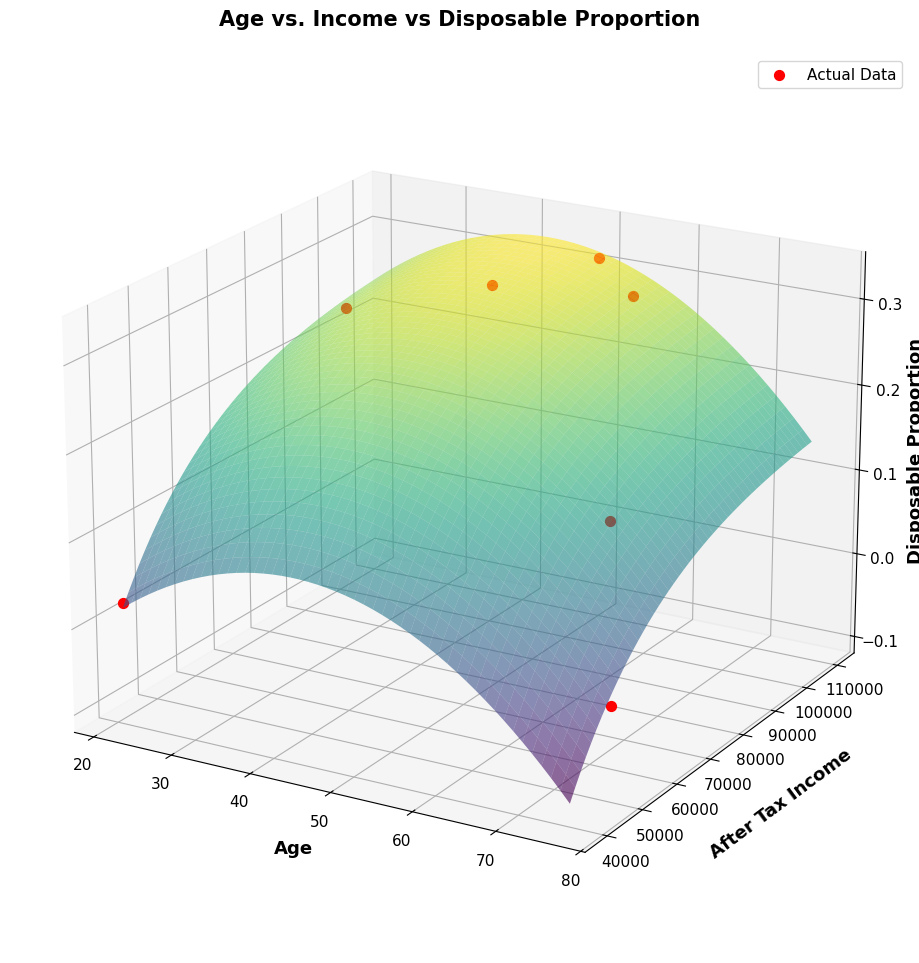

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#ANOTHER POSSIBILITY: graph neccessary income vs age and then subtract that flat amount from inputted after tax income

#change US numbers and do UK

#--legacy info
after_tax_not_including_married = np.array([39089.66,	76376.54,	93247.69,	101475.56,	88944.01,	58507.06, 	44807.81]) 
disposable_income_not_including_married = np.array([-4041.35,	5505.54, 5262.69, 9119.56 ,9024.01,	-3888.94 ,-8800.19])



#assuming everyone above 29.5 is married and everyone below is single 
age = np.array([(25+18)/2, (34+25)/2, (44+35)/2, (54+45)/2, (64+55)/2, (74+65)/2, (78+75)/2]) #averaging age brackets, maybe make better lattr
after_tax = np.array([ 39047.66,	 82254.94,	101881.89,	110383.18,	96772.53,	66360.58,	50368.04 ])
disposable_income = np.array([991.65,	22947.94,	28563.89,	34201.18,	30047.53,	9360.58, -597.96])
# plt.title("Age vs disposable income")
# plt.scatter(age, disposable_income)
# plt.show()


proportion = disposable_income/after_tax

def age_prop_reg():
    plt.title("Age vs Proportion of after tax income (state) that is disposable")
    plt.scatter(age, disposable_income/after_tax)
    #plt.show()

    #interperet age vs proportion disposable income as quartic?? to model mid-life dip due to children entering the house but then leaving house


    X = np.stack([age ** 2, age, np.ones_like(age)]).transpose()
    print(X)

    w = np.linalg.pinv(X) @ proportion
    print(w)

    plt.plot(age, X @ w)
    plt.show()

def show_income_vs_proportion():
    plt.title("Income vs Proportion of after tax income (state) that is disposable")
    X = np.stack([after_tax, np.ones_like(after_tax)]).transpose()
    w = np.linalg.pinv(X) @ proportion
    plt.scatter(after_tax, disposable_income/after_tax)
    print("INCOME VS DISP PROP WEIGHTs", w)
    plt.plot(after_tax, X @ w)
    plt.show()

#CHEF MIKED PLOTRTING FUNC
def plot_3d_regression(age, after_tax, proportion, w):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. Create a grid of values to draw the smooth surface
    age_grid = np.linspace(age.min(), age.max(), 50)
    tax_grid = np.linspace(after_tax.min(), after_tax.max(), 50)
    age_mesh, tax_mesh = np.meshgrid(age_grid, tax_grid)
    
    # 2. Calculate the predicted proportion (Z) for every point on the grid
    # w[0] = age^2, w[1] = age, w[2] = after_tax, w[3] = constant
    Z = w[0] * age_mesh**2 + w[1] * age_mesh + w[2] * tax_mesh + w[3]
    
    # 3. Plot the predicted surface and the actual data points
    ax.plot_surface(age_mesh, tax_mesh, Z, alpha=0.6, cmap='viridis')
    ax.scatter(age, after_tax, proportion, color='red', s=50, label='Actual Data', depthshade=False)
    
    # 4. Labels and display
    ax.set_xlabel('Age')
    ax.set_ylabel('After Tax Income')
    ax.set_zlabel('Disposable Proportion')
    ax.set_title('3D Regression: Age & Income vs Disposable Proportion')
    plt.legend()
    plt.show()


#--- switching over to EXPONENTIAL relationship between income and disp instead of linear

def show_income_vs_proportion_exp():
    plt.title("Income vs Proportion of after tax income (state) that is disposable")
    
    # Define the 1D exponential decay model
    def exp_model(x, a, b, c):
        return a * np.exp(b * x) + c
    
    # Provide an initial guess [a, b, c] so the optimizer doesn't get lost
    p0 = [-1.0, -0.00005, 0.5]
    popt, _ = curve_fit(exp_model, after_tax, proportion, p0=p0, maxfev=10000)
    
    print("INCOME VS DISP PROP EXP WEIGHTS (a, b, c):", popt)
    
    # Plot original scatter
    plt.scatter(after_tax, proportion, label="Actual Data")
    
    # Plot smooth exponential curve
    tax_sorted = np.linspace(after_tax.min(), after_tax.max(), 100)
    plt.plot(tax_sorted, exp_model(tax_sorted, *popt), color='red', label="Exp Fit")
    
    plt.legend()
    plt.show()

def linear_income_quad_age_reg(): #legacy
    print("--- Running Original Linear(Income) / Quad(Age) 3D Regression ---")
    
    X = np.stack([age ** 2, age, after_tax, np.ones_like(age)]).transpose()
    w = np.linalg.pinv(X) @ proportion
    
    print("Linear/Quad 3D Weights:", w)
    
    plot_3d_regression(age, after_tax, proportion, w)

def exp_income_quad_age_reg():
    print("--- Running New Exp(Income) / Quad(Age) 3D Regression ---")
    
    def exp_quad_model(X_data, a, b, c, d, f):
        tax_val, age_val = X_data
        return a * np.exp(b * tax_val) + c * (age_val**2) + d * age_val + f

    p0 = [-0.5, -0.00001, 0.0001, 0.01, 0.5]
    popt, _ = curve_fit(exp_quad_model, (after_tax, age), proportion, p0=p0, maxfev=10000)
    
    print("Exp/Quad 3D Weights (a, b, c, d, f):", popt)

    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    age_grid = np.linspace(age.min(), age.max(), 50)
    tax_grid = np.linspace(after_tax.min(), after_tax.max(), 50)
    age_mesh, tax_mesh = np.meshgrid(age_grid, tax_grid)
    
    Z = exp_quad_model((tax_mesh, age_mesh), *popt)
    
    ax.plot_surface(age_mesh, tax_mesh, Z, alpha=0.6, cmap='viridis')
    ax.scatter(age, after_tax, proportion, color='red', s=50, label='Actual Data', depthshade=False)
    
    ax.view_init(elev=20, azim=-60)
    ax.dist = 12

    ax.set_xlabel('Age', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel('After Tax Income', fontsize=13, fontweight='bold', labelpad=15)

    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel('Disposable Proportion', fontsize=13, fontweight='bold', rotation=90)

    ax.set_title('Age vs. Income vs Disposable Proportion', fontsize=15, fontweight='bold', pad=20)
    ax.tick_params(axis='both', which='major', labelsize=11)
    plt.legend(fontsize=11)
    plt.subplots_adjust(left=0.1, right=1.5, bottom=0.15, top=0.9)

    plt.savefig('US_MODEL.png', dpi=150, bbox_inches='tight', pad_inches=1)
    plt.show()

exp_income_quad_age_reg()
